# Interactive Snapshot Viewer

In [1]:
import os, glob
import numpy as np
import h5py
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# ── config ───────────────────────────────────────────────────────────────────
SNAPSHOT_DIR = './snapshots_small_blob_11'
# ─────────────────────────────────────────────────────────────────────────────

def find_snapshots():
    return sorted(glob.glob(os.path.join(SNAPSHOT_DIR, 'batch_*.hdf')))

def center_crop(arr, target_shape):
    """Crop arr to target_shape from the centre (last 3 spatial dims)."""
    slices = [slice(None)] * (arr.ndim - 3)
    for a, t in zip(arr.shape[-3:], target_shape[-3:]):
        start = (a - t) // 2
        slices.append(slice(start, start + t))
    return arr[tuple(slices)]

def load_snapshot(path):
    with h5py.File(path, 'r') as f:
        pred_mask = f['volumes/pred_post_indicator'][:].astype(np.float32)
        pred_vec  = f['volumes/pred_postpre_vectors'][:].astype(np.float32)
        raw       = f['volumes/raw'][:].astype(np.float32)
        gt_mask   = f['volumes/gt_post_indicator'][:].astype(np.float32)
        gt_vec    = f['volumes/gt_postpre_vectors'][:].astype(np.float32)
    # center-crop GT and raw to match pred spatial size
    gt_mask = center_crop(gt_mask, pred_mask.shape)
    gt_vec  = center_crop(gt_vec,  pred_vec.shape)
    raw     = center_crop(raw,     pred_mask.shape)
    # detect old snapshots where mask/vec were saved swapped
    # pred_mask should be (Z,Y,X), pred_vec should be (3,Z,Y,X)
    if pred_vec.shape[0] == 1 and pred_mask.ndim == 3:
        # old snapshot: pred_vec is actually mask, pred_mask is actually vec
        pred_vec, pred_mask = pred_mask, pred_vec[0]
        print(f'  ⚠ old snapshot detected — mask/vec were swapped, correcting')
    elif pred_vec.ndim == 3 and pred_mask.shape[0] == 3:
        pred_vec, pred_mask = pred_mask, pred_vec
        print(f'  ⚠ old snapshot detected — mask/vec were swapped, correcting')
    return {
        'raw':       raw,
        'gt_mask':   gt_mask,
        'gt_vec':    gt_vec,
        'pred_mask': pred_mask,
        'pred_vec':  pred_vec,
    }

def normalise(arr):
    lo, hi = arr.min(), arr.max()
    return (arr - lo) / max(hi - lo, 1e-8)

def compute_metrics(d):
    p_fg = d['pred_mask'][d['gt_mask'] > 0.5]
    p_bg = d['pred_mask'][d['gt_mask'] < 0.5]
    sep  = float(p_fg.mean() - p_bg.mean()) if len(p_fg) > 0 else 0.0
    blob = d['gt_mask'] > 0.5
    if blob.any():
        gv = d['gt_vec'][:, blob]
        pv = d['pred_vec'][:, blob]
        gn = gv / (np.linalg.norm(gv, axis=0, keepdims=True) + 1e-8)
        pn = pv / (np.linalg.norm(pv, axis=0, keepdims=True) + 1e-8)
        cos = float((gn * pn).sum(axis=0).mean())
    else:
        cos = 0.0
    return sep, cos

snaps = find_snapshots()
print(f'Found {len(snaps)} snapshot(s) in {SNAPSHOT_DIR}/')
for s in snaps:
    print(f'  {os.path.basename(s)}  ({os.path.getsize(s)/1e6:.1f} MB)')

Found 2 snapshot(s) in ./snapshots_small_blob_11/
  batch_00010000.hdf  (65.0 MB)
  batch_00020000.hdf  (60.6 MB)


In [2]:
if not snaps:
    print('No snapshots yet — training saves one every 25k iterations.')
else:
    snap_names = [os.path.basename(p) for p in snaps]

    snap_sel = widgets.Select(
        options=list(zip(snap_names, snaps)),
        value=snaps[-1],
        description='Snapshot:',
        layout=widgets.Layout(width='320px', height='120px'),
    )
    z_slider = widgets.IntSlider(
        min=0, max=53, step=1, value=27,
        description='z slice:',
        continuous_update=False,
        layout=widgets.Layout(width='420px'),
    )
    alpha_slider = widgets.FloatSlider(
        min=0.0, max=1.0, step=0.05, value=0.5,
        description='overlay alpha:',
        continuous_update=False,
        layout=widgets.Layout(width='420px'),
    )
    conf_slider = widgets.FloatSlider(
        min=0.0, max=1.0, step=0.01, value=0.0,
        description='conf min:',
        continuous_update=False,
        layout=widgets.Layout(width='420px'),
    )
    mode_toggle = widgets.ToggleButtons(
        options=['Indicator', 'Vectors', 'Both'],
        value='Both',
        description='View:',
    )
    prev_btn = widgets.Button(description='< prev z', layout=widgets.Layout(width='100px'))
    next_btn = widgets.Button(description='next z >', layout=widgets.Layout(width='100px'))
    syn_btn  = widgets.Button(description='jump to synapse z', button_style='warning',
                              layout=widgets.Layout(width='160px'))
    refresh_btn = widgets.Button(description='refresh snapshots', button_style='info',
                                 layout=widgets.Layout(width='160px'))
    metrics_out = widgets.Output()
    plot_out    = widgets.Output()

    _cache = {}
    _syn_idx = [0]

    def get_data(path):
        if path not in _cache:
            _cache.clear()
            _cache[path] = load_snapshot(path)
        return _cache[path]

    def render(_=None):
        path  = snap_sel.value
        z     = z_slider.value
        alpha = alpha_slider.value
        conf  = conf_slider.value
        mode  = mode_toggle.value
        d     = get_data(path)

        z_slider.max = d['raw'].shape[0] - 1
        z = min(z, z_slider.max)
        raw_d = normalise(d['raw'])

        pred_display = d['pred_mask'].copy()
        pred_display[pred_display < conf] = 0.0
        sep, cos = compute_metrics(d)
        syn_z = np.where(d['gt_mask'].max(axis=(1, 2)) > 0)[0]

        with metrics_out:
            clear_output(wait=True)
            p_fg = d['pred_mask'][d['gt_mask'] > 0.5]
            p_bg = d['pred_mask'][d['gt_mask'] < 0.5]
            fg_str = f'{p_fg.mean():.3f}' if len(p_fg) > 0 else 'n/a'
            print(f"  file   : {os.path.basename(path)}")
            print(f"  shape  : {d['raw'].shape}")
            print(f"  GT fg  : {int(d['gt_mask'].sum())} vox  ({d['gt_mask'].mean()*100:.3f}%)")
            print(f"  pred@fg: {fg_str}  pred@bg: {p_bg.mean():.3f}")
            print(f"  sep    : {sep:.3f}   cos: {cos:.3f}")
            syn_z_str = str(syn_z.tolist()) if len(syn_z) else 'none'
            print(f"  syn z  : {syn_z_str}")
            has_syn_here = d['gt_mask'][z].max() > 0
            print(f"  this z : {'★ HAS SYNAPSES' if has_syn_here else 'no synapses'}")

        with plot_out:
            clear_output(wait=True)
            vmx = max(abs(d['gt_vec']).max(), 1e-3)
            has_syn_here = d['gt_mask'][z].max() > 0
            title_suffix = '  ★ GT synapses here' if has_syn_here else ''

            if mode == 'Indicator':
                fig, axes = plt.subplots(1, 4, figsize=(18, 4))
                axes[0].imshow(raw_d[z],           cmap='gray', vmin=0, vmax=1)
                axes[0].set_title('raw')
                axes[1].imshow(d['gt_mask'][z],    cmap='hot',  vmin=0, vmax=1)
                axes[1].set_title('GT indicator')
                axes[2].imshow(pred_display[z],    cmap='hot',  vmin=0, vmax=1)
                axes[2].set_title(f'pred (conf>{conf:.2f})')
                axes[3].imshow(raw_d[z],           cmap='gray', vmin=0, vmax=1)
                axes[3].imshow(pred_display[z],    cmap='hot',  vmin=0, vmax=1, alpha=alpha)
                axes[3].set_title('overlay')
                for ax in axes: ax.axis('off')

            elif mode == 'Vectors':
                fig, axes = plt.subplots(2, 4, figsize=(18, 8))
                for c, lbl in enumerate(['z', 'y', 'x']):
                    axes[0, c].imshow(d['gt_vec'][c, z],   cmap='bwr', vmin=-vmx, vmax=vmx)
                    axes[0, c].set_title(f'GT vec {lbl}')
                    axes[1, c].imshow(d['pred_vec'][c, z], cmap='bwr', vmin=-vmx, vmax=vmx)
                    axes[1, c].set_title(f'pred vec {lbl}')
                axes[0, 3].imshow(np.linalg.norm(d['gt_vec'][:, z],   axis=0), cmap='viridis')
                axes[0, 3].set_title('GT magnitude')
                axes[1, 3].imshow(np.linalg.norm(d['pred_vec'][:, z], axis=0), cmap='viridis')
                axes[1, 3].set_title('pred magnitude')
                axes[0, 0].set_ylabel('ground truth', fontsize=10)
                axes[1, 0].set_ylabel('prediction',   fontsize=10)
                for row in axes:
                    for ax in row: ax.axis('off')

            else:  # Both — show indicator + all 3 vector channels
                fig, axes = plt.subplots(3, 4, figsize=(18, 12))
                # row 0: indicator
                axes[0, 0].imshow(raw_d[z],         cmap='gray', vmin=0, vmax=1)
                axes[0, 0].set_title('raw')
                axes[0, 1].imshow(d['gt_mask'][z],  cmap='hot',  vmin=0, vmax=1)
                axes[0, 1].set_title('GT indicator')
                axes[0, 2].imshow(pred_display[z],  cmap='hot',  vmin=0, vmax=1)
                axes[0, 2].set_title(f'pred (conf>{conf:.2f})')
                axes[0, 3].imshow(raw_d[z],         cmap='gray', vmin=0, vmax=1)
                axes[0, 3].imshow(pred_display[z],  cmap='hot',  vmin=0, vmax=1, alpha=alpha)
                axes[0, 3].set_title('overlay')
                axes[0, 0].set_ylabel('indicator', fontsize=10)
                # rows 1-2: GT vs pred for z, y, x vectors
                for ci, lbl in enumerate(['z', 'y', 'x']):
                    vscale = max(abs(d['gt_vec'][ci]).max(), abs(d['pred_vec'][ci]).max(), 1e-3)
                    axes[1, ci].imshow(d['gt_vec'][ci, z],   cmap='bwr', vmin=-vscale, vmax=vscale)
                    axes[1, ci].set_title(f'GT vec {lbl}')
                    axes[2, ci].imshow(d['pred_vec'][ci, z], cmap='bwr', vmin=-vscale, vmax=vscale)
                    axes[2, ci].set_title(f'pred vec {lbl}')
                axes[1, 3].imshow(np.linalg.norm(d['gt_vec'][:, z],   axis=0), cmap='viridis')
                axes[1, 3].set_title('GT magnitude')
                axes[2, 3].imshow(np.linalg.norm(d['pred_vec'][:, z], axis=0), cmap='viridis')
                axes[2, 3].set_title('pred magnitude')
                axes[1, 0].set_ylabel('GT vectors',   fontsize=10)
                axes[2, 0].set_ylabel('pred vectors', fontsize=10)
                for row in axes:
                    for ax in row: ax.axis('off')

            fig.suptitle(f"{os.path.basename(path)}  z={z}{title_suffix}", fontsize=12)
            plt.tight_layout()
            plt.show()

    def on_prev(_):
        z_slider.value = max(0, z_slider.value - 1)

    def on_next(_):
        z_slider.value = min(z_slider.max, z_slider.value + 1)

    def on_jump_syn(_):
        d = get_data(snap_sel.value)
        syn_z = np.where(d['gt_mask'].max(axis=(1, 2)) > 0)[0]
        if len(syn_z) == 0:
            return
        _syn_idx[0] = (_syn_idx[0] + 1) % len(syn_z)
        z_slider.value = int(syn_z[_syn_idx[0]])

    def on_refresh(_):
        new_snaps = find_snapshots()
        new_names = [os.path.basename(p) for p in new_snaps]
        snap_sel.options = list(zip(new_names, new_snaps))
        if new_snaps:
            snap_sel.value = new_snaps[-1]

    for w in [snap_sel, z_slider, alpha_slider, conf_slider, mode_toggle]:
        w.observe(render, names='value')
    prev_btn.on_click(on_prev)
    next_btn.on_click(on_next)
    syn_btn.on_click(on_jump_syn)
    refresh_btn.on_click(on_refresh)

    controls = widgets.VBox([
        widgets.HBox([snap_sel, refresh_btn]),
        z_slider,
        widgets.HBox([prev_btn, next_btn, syn_btn]),
        alpha_slider,
        conf_slider,
        mode_toggle,
        metrics_out,
    ])
    display(controls, plot_out)
    render()


Output()

In [8]:
# # ── Progress across all snapshots ────────────────────────────────────────────
# snaps = find_snapshots()
# if len(snaps) < 2:
#     print('Need at least 2 snapshots for a progress plot.')
# else:
#     iters, seps, cosims, fg_means = [], [], [], []
#     prog = widgets.IntProgress(min=0, max=len(snaps), description='Loading...')
#     display(prog)
#     for i, path in enumerate(snaps):
#         it = int(os.path.basename(path).replace('batch_', '').replace('.hdf', ''))
#         d  = load_snapshot(path)
#         sep, cos = compute_metrics(d)
#         p_fg = d['pred_mask'][d['gt_mask'] > 0.3]
#         fg_means.append(float(p_fg.mean()) if len(p_fg) > 0 else 0.0)
#         iters.append(it); seps.append(sep); cosims.append(cos)
#         prog.value = i + 1
#     prog.description = 'Done'

#     fig, axes = plt.subplots(1, 3, figsize=(18, 4))
#     axes[0].plot(iters, fg_means, 'o-', color='crimson',   lw=2)
#     axes[0].set_title('pred @ GT fg  (want 1.0)')
#     axes[0].set_ylim(0, 1); axes[0].axhline(0.5, color='gray', ls='--', lw=0.8)
#     axes[1].plot(iters, seps,    'o-', color='darkorange', lw=2)
#     axes[1].set_title('fg/bg separation  (want large)')
#     axes[1].axhline(0, color='gray', ls='--', lw=0.8)
#     axes[2].plot(iters, cosims,  'o-', color='steelblue',  lw=2)
#     axes[2].set_title('vector cosine similarity  (want 1.0)')
#     axes[2].set_ylim(-1, 1); axes[2].axhline(0, color='gray', ls='--', lw=0.8)
#     for ax in axes:
#         ax.set_xlabel('iteration')
#         ax.grid(alpha=0.3)
#     plt.tight_layout()
#     plt.show()

64 raw clusters at conf>0.98  |  9 GT post sites
53 detections after size filter
51 detections after NMS (r=10)


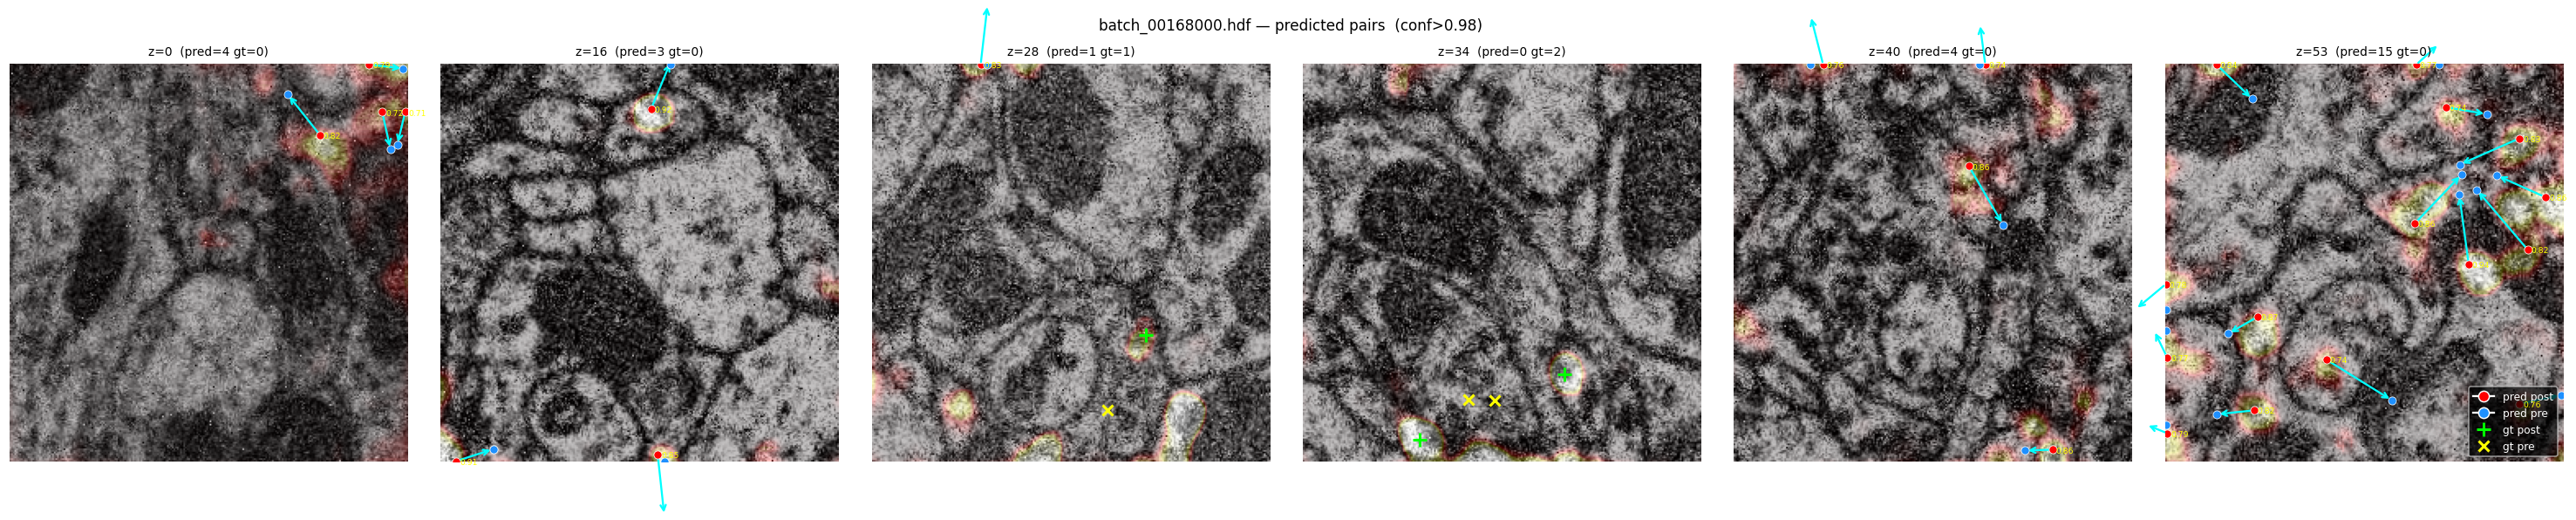

GT: 9  Pred: 51  TP: 5  (20-vox tolerance)
Precision=0.10  Recall=0.56  F1=0.17


In [10]:
# ── Predicted synaptic pairs: post (red) → pre (blue) ────────────────────────
from scipy import ndimage as ndi

# ── params ───────────────────────────────────────────────────────────────────
snap_path  = snaps[-1]   # change to any snapshot
conf_thr   = 0.98      # match your conf min slider
size_thr   = 5           # min voxels per detection
nms_radius = 10          # suppress detections within this many vox
# ─────────────────────────────────────────────────────────────────────────────

d     = load_snapshot(snap_path)
raw_d = normalise(d['raw'])

# ── GT post + pre centroids ──────────────────────────────────────────────────
gt_lbl, n_gt = ndi.label(d['gt_mask'] > conf_thr)
gt_cents     = np.array(ndi.center_of_mass(d['gt_mask'], gt_lbl, range(1, n_gt+1))) if n_gt > 0 else np.zeros((0,3))
gt_pre_cents = []
for gc in gt_cents:
    iz = int(np.clip(round(gc[0]), 0, d['gt_vec'].shape[1]-1))
    iy = int(np.clip(round(gc[1]), 0, d['gt_vec'].shape[2]-1))
    ix = int(np.clip(round(gc[2]), 0, d['gt_vec'].shape[3]-1))
    vec = np.array([d['gt_vec'][0,iz,iy,ix], d['gt_vec'][1,iz,iy,ix], d['gt_vec'][2,iz,iy,ix]])
    gt_pre_cents.append(gc + vec)
gt_pre_cents = np.array(gt_pre_cents) if len(gt_pre_cents) else np.zeros((0,3))

# threshold + connected components
binary      = (d['pred_mask'] > 0.7).astype(np.uint8)
labeled, n  = ndi.label(binary)
print(f'{n} raw clusters at conf>{conf_thr}  |  {n_gt} GT post sites')

if n == 0:
    print('No detections — lower conf_thr')
else:
    post_centroids = []
    pre_predicted  = []
    scores         = []

    for lbl in range(1, n + 1):
        mask = labeled == lbl
        if mask.sum() < size_thr:
            continue

        score = float(d['pred_mask'][mask].mean())

        edt   = ndi.distance_transform_edt(mask)
        cz, cy, cx = np.unravel_index(edt.argmax(), edt.shape)
        post  = np.array([float(cz), float(cy), float(cx)])

        vz = float(d['pred_vec'][0][mask].mean())
        vy = float(d['pred_vec'][1][mask].mean())
        vx = float(d['pred_vec'][2][mask].mean())
        vec = np.array([vz, vy, vx])

        pre = post + vec
        post_centroids.append(post)
        pre_predicted.append(pre)
        scores.append(score)

    post_centroids = np.array(post_centroids)
    pre_predicted  = np.array(pre_predicted)
    scores         = np.array(scores)
    print(f'{len(post_centroids)} detections after size filter')

    # NMS
    if nms_radius > 0 and len(post_centroids) > 1:
        order      = np.argsort(scores)[::-1]
        kept       = []
        suppressed = set()
        for i in order:
            if i in suppressed:
                continue
            kept.append(i)
            for j in order:
                if j != i and j not in suppressed:
                    if np.linalg.norm(post_centroids[i] - post_centroids[j]) < nms_radius:
                        suppressed.add(j)
        post_centroids = post_centroids[kept]
        pre_predicted  = pre_predicted[kept]
        scores         = scores[kept]
        print(f'{len(post_centroids)} detections after NMS (r={nms_radius})')

    # pick z slices that have detections or GT
    all_z  = list(post_centroids[:,0].astype(int))
    if len(gt_cents): all_z += list(gt_cents[:,0].astype(int))
    det_z  = np.unique(all_z)
    n_show = min(len(det_z), 6)
    show_z = det_z[np.linspace(0, len(det_z)-1, n_show, dtype=int)]

    fig, axes = plt.subplots(1, len(show_z), figsize=(4.5*len(show_z), 5))
    if len(show_z) == 1:
        axes = [axes]

    for ax, z in zip(axes, show_z):
        z = int(z)
        ax.imshow(raw_d[z], cmap='gray', vmin=0, vmax=1)
        ax.imshow(d['pred_mask'][z], cmap='hot', vmin=0, vmax=1, alpha=0.25)

        # GT post (green +) and GT pre (yellow x)
        if len(gt_cents):
            gt_near = np.abs(gt_cents[:,0] - z) < 2
            for gc in gt_cents[gt_near]:
                ax.plot(gc[2], gc[1], '+', color='lime', ms=10, mew=2, zorder=6)
        if len(gt_pre_cents):
            gtp_near = np.abs(gt_pre_cents[:,0] - z) < 2
            for gp in gt_pre_cents[gtp_near]:
                ax.plot(gp[2], gp[1], 'x', color='yellow', ms=8, mew=2, zorder=6)

        # predicted pairs
        near = np.abs(post_centroids[:,0] - z) < 2
        for post, pre, sc in zip(post_centroids[near], pre_predicted[near], scores[near]):
            py, px = post[1], post[2]
            ry, rx = pre[1],  pre[2]
            ax.plot(px, py, 'o', color='red', ms=6, zorder=5,
                    markeredgewidth=0.5, markeredgecolor='white')
            rx_c = float(np.clip(rx, 0, d['raw'].shape[2]-1))
            ry_c = float(np.clip(ry, 0, d['raw'].shape[1]-1))
            ax.plot(rx_c, ry_c, 'o', color='dodgerblue', ms=6, zorder=5,
                    markeredgewidth=0.5, markeredgecolor='white')
            ax.annotate('', xy=(rx, ry), xytext=(px, py),
                        arrowprops=dict(arrowstyle='->', color='cyan', lw=1.5),
                        annotation_clip=False)
            ax.text(px+2, py+2, f'{sc:.2f}', color='yellow', fontsize=6, zorder=6)

        n_gt_near = len(gt_cents[np.abs(gt_cents[:,0] - z) < 2]) if len(gt_cents) else 0
        ax.set_title(f'z={z}  (pred={near.sum()} gt={n_gt_near})', fontsize=9)
        ax.axis('off')

    from matplotlib.lines import Line2D
    axes[-1].legend(
        handles=[
            Line2D([0],[0], marker='o', color='w', markerfacecolor='red',        ms=8, label='pred post'),
            Line2D([0],[0], marker='o', color='w', markerfacecolor='dodgerblue', ms=8, label='pred pre'),
            Line2D([0],[0], marker='+', color='lime',   ms=10, mew=2, lw=0,      label='gt post'),
            Line2D([0],[0], marker='x', color='yellow', ms=8,  mew=2, lw=0,      label='gt pre'),
        ],
        loc='lower right', fontsize=8, framealpha=0.7,
        facecolor='black', labelcolor='white'
    )
    fig.suptitle(f'{os.path.basename(snap_path)} — predicted pairs  (conf>{conf_thr})', fontsize=11)
    plt.tight_layout()
    plt.show()

    # F1 using GT centroids
    if n_gt > 0 and len(post_centroids) > 0:
        from scipy.spatial.distance import cdist
        dists = cdist(post_centroids, gt_cents)
        tp   = (dists.min(axis=1) < 20).sum()
        prec = tp / len(post_centroids)
        rec  = tp / n_gt
        f1   = 2*prec*rec / (prec+rec+1e-8)
        print(f'GT: {n_gt}  Pred: {len(post_centroids)}  TP: {tp}  (20-vox tolerance)')
        print(f'Precision={prec:.2f}  Recall={rec:.2f}  F1={f1:.2f}')


In [4]:

# ── Neuroglancer viewer for snapshot ─────────────────────────────────────────
import neuroglancer
import numpy as np
from scipy import ndimage as ndi

snap_path = snaps[-1]   # change to any snapshot
d = load_snapshot(snap_path)

neuroglancer.set_server_bind_address('127.0.0.1')
viewer = neuroglancer.Viewer()

voxel_size = [1, 1, 1]

# ── params ───────────────────────────────────────────────────────────────────
conf_thr   = 0.9
min_size   = 10
vec_scale  = 1    # >1 stretches vector toward pre site
# ─────────────────────────────────────────────────────────────────────────────

def czyx_vol_dims():
    return neuroglancer.CoordinateSpace(
        names=['c^','z','y','x'], units=['','','',''], scales=[1]+voxel_size)

raw_sz  = np.array(d['raw'].shape)
pred_sz = np.array(d['pred_mask'].shape)
offset_zyx = ((raw_sz - pred_sz) // 2).tolist()

with viewer.txn() as s:
    s.dimensions = neuroglancer.CoordinateSpace(
        names=['x','y','z'], units=['','',''], scales=voxel_size)

    s.layers['raw'] = neuroglancer.ImageLayer(
        source=neuroglancer.LocalVolume(
            data=d['raw'][np.newaxis],
            dimensions=czyx_vol_dims(),
            voxel_offset=[0, 0, 0, 0],
        ),
        shader='#uicontrol invlerp normalized\nvoid main(){emitGrayscale(normalized());}',
    )

    s.layers['pred_indicator'] = neuroglancer.ImageLayer(
        source=neuroglancer.LocalVolume(
            data=d['pred_mask'][np.newaxis],
            dimensions=czyx_vol_dims(),
            voxel_offset=[0] + offset_zyx,
        ),
        shader='#uicontrol invlerp normalized(range=[0,1])\nvoid main(){float v=normalized();emitRGBA(vec4(v,0,0,v*0.6));}',
    )

    s.layers['gt_indicator'] = neuroglancer.ImageLayer(
        source=neuroglancer.LocalVolume(
            data=d['gt_mask'][np.newaxis],
            dimensions=czyx_vol_dims(),
            voxel_offset=[0] + offset_zyx,
        ),
        shader='#uicontrol invlerp normalized(range=[0,1])\nvoid main(){float v=normalized();emitRGBA(vec4(0,v,0,v*0.5));}',
    )
    s.layers['gt_indicator'].visible = False

    vec_mag = np.linalg.norm(d['pred_vec'], axis=0)
    s.layers['pred_vec_mag'] = neuroglancer.ImageLayer(
        source=neuroglancer.LocalVolume(
            data=vec_mag[np.newaxis],
            dimensions=czyx_vol_dims(),
            voxel_offset=[0] + offset_zyx,
        ),
    )
    s.layers['pred_vec_mag'].visible = False

    off = np.array(offset_zyx, dtype=float)
    binary = (d['pred_mask'] > conf_thr).astype(np.uint8)

    labeled, n = ndi.label(binary)
    annotations = []
    for lbl in range(1, n + 1):
        mask = labeled == lbl
        if mask.sum() < min_size:
            continue
        cz, cy, cx = ndi.center_of_mass(mask)
        post_zyx = np.array([cz, cy, cx]) + off
        iz = int(np.clip(round(cz), 0, d['pred_vec'].shape[1]-1))
        iy = int(np.clip(round(cy), 0, d['pred_vec'].shape[2]-1))
        ix = int(np.clip(round(cx), 0, d['pred_vec'].shape[3]-1))
        vec_zyx = np.array([
            float(d['pred_vec'][0, iz, iy, ix]),
            float(d['pred_vec'][1, iz, iy, ix]),
            float(d['pred_vec'][2, iz, iy, ix]),
        ]) * vec_scale
        pre_zyx = post_zyx + vec_zyx
        post_xyz = [post_zyx[2], post_zyx[1], post_zyx[0]]
        pre_xyz  = [pre_zyx[2],  pre_zyx[1],  pre_zyx[0]]
        annotations.append(neuroglancer.LineAnnotation(
            point_a=post_xyz,
            point_b=pre_xyz,
            id=str(lbl),
        ))

    s.layers['pairs'] = neuroglancer.AnnotationLayer(
        annotations=annotations,
        annotation_color='#ff4400',
    )

    s.position = [float(raw_sz[2]//2), float(raw_sz[1]//2), float(raw_sz[0]//2)]
    s.cross_section_scale = 1.5

print(f'{len(annotations)} annotations shown')
print(viewer)


39 annotations shown
http://127.0.0.1:37979/v/5b3f933bcb5ee85faeffd8919536531dd0ccc399/


In [16]:

# ── Print vector stats for latest snapshot ───────────────────────────────────
import numpy as np
from scipy import ndimage as ndi

snap_path = snaps[-1]
d = load_snapshot(snap_path)

conf_thr = 0.5
binary = (d['pred_mask'] > conf_thr).astype(np.uint8)
labeled, n = ndi.label(binary)

print(f'{"lbl":>4}  {"post_zyx":>20}  {"vec_z":>8}  {"vec_y":>8}  {"vec_x":>8}  {"|vec|":>8}')
for lbl in range(1, n+1):
    mask = labeled == lbl
    if mask.sum() < 3:
        continue
    cz, cy, cx = ndi.center_of_mass(mask)
    iz = int(np.clip(round(cz), 0, d['pred_vec'].shape[1]-1))
    iy = int(np.clip(round(cy), 0, d['pred_vec'].shape[2]-1))
    ix = int(np.clip(round(cx), 0, d['pred_vec'].shape[3]-1))
    vz = d['pred_vec'][0, iz, iy, ix]
    vy = d['pred_vec'][1, iz, iy, ix]
    vx = d['pred_vec'][2, iz, iy, ix]
    mag = np.sqrt(vz**2 + vy**2 + vx**2)
    print(f'{lbl:>4}  ({cz:6.1f},{cy:6.1f},{cx:6.1f})  {vz:>8.3f}  {vy:>8.3f}  {vx:>8.3f}  {mag:>8.3f}')

# also print GT vectors for comparison
print('\nGT vector stats at same locations:')
gt_labeled, n_gt = ndi.label(d['gt_mask'] > 0.5)
print(f'{"lbl":>4}  {"gt_cent_zyx":>20}  {"gt_vz":>8}  {"gt_vy":>8}  {"gt_vx":>8}')
for lbl in range(1, n_gt+1):
    mask = gt_labeled == lbl
    if mask.sum() < 3:
        continue
    cz, cy, cx = ndi.center_of_mass(mask)
    iz = int(np.clip(round(cz), 0, d['gt_vec'].shape[1]-1))
    iy = int(np.clip(round(cy), 0, d['gt_vec'].shape[2]-1))
    ix = int(np.clip(round(cx), 0, d['gt_vec'].shape[3]-1))
    vz = d['gt_vec'][0, iz, iy, ix]
    vy = d['gt_vec'][1, iz, iy, ix]
    vx = d['gt_vec'][2, iz, iy, ix]
    print(f'{lbl:>4}  ({cz:6.1f},{cy:6.1f},{cx:6.1f})  {vz:>8.3f}  {vy:>8.3f}  {vx:>8.3f}')


 lbl              post_zyx     vec_z     vec_y     vec_x     |vec|
   1  (   0.0,   1.1,  94.9)    -0.038     3.062    33.094    33.235
   3  (   0.9,   2.1, 171.1)     0.724    20.109   -35.844    41.106
   5  (   0.8,  27.1, 162.6)     1.963    -2.285   -23.859    24.049
   6  (   1.5,  59.6, 146.3)    -0.113   -15.867     3.506    16.250
   7  (   1.1, 100.9,  81.1)     0.044    24.562    22.797    33.511
   8  (   1.3, 108.1,   7.6)    -0.208   -31.906     6.695    32.602
   9  (   1.8, 123.5,  67.9)     2.426     3.609    34.938    35.207
  10  (   1.7, 152.1,  71.0)     2.209   -19.109    34.500    39.501
  11  (   0.2, 157.5,  91.9)     0.978   -23.875    17.969    29.897
  12  (   1.2, 215.8,  16.0)     1.357    34.500   -13.656    37.129
  13  (   0.0, 233.0,  75.0)    -1.032    14.883    -5.922    16.051
  14  (   1.2, 239.3, 154.7)     0.513    24.344     5.781    25.026
  15  (   2.0, 172.2, 241.8)    -0.088    -1.646    29.625    29.671
  17  (   4.3, 200.3,  58.2)    -1.5